# Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# loading the data

In [3]:
df=pd.read_csv('/content/loan_data_new.csv')

# Understanding the data

In [4]:
# show shape
df.shape

(45000, 14)

In [5]:
# check first 5 rows
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [6]:
# column names
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

In [7]:
# cleaning the columns names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [8]:
df.columns

Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_onwership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')

In [9]:
# info(float,int,catagory)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  45000 non-null  int64  
 1   gender               45000 non-null  object 
 2   education            45000 non-null  object 
 3   person_income        45000 non-null  int64  
 4   employee_experience  45000 non-null  int64  
 5   home_onwership       45000 non-null  object 
 6   loan_amount          45000 non-null  int64  
 7   loan_intent          45000 non-null  object 
 8   loan_interest_rate   45000 non-null  float64
 9   loan_percentage      45000 non-null  float64
 10  credit_history       45000 non-null  int64  
 11  credit_score         45000 non-null  int64  
 12  previous_loan        45000 non-null  object 
 13  loan_status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [10]:
# statistical summary
df.describe()

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Data handling & EDA

In [11]:
# show some sample to know (null values,target column ,outliars)
df.head(10)

,age,gender,education,person_income,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471,1,RENT,35000,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550,5,RENT,35000,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684,3,RENT,35000,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739,0,OWN,1600,VENTURE,14.74,0.13,3,640,No,1


In [12]:
# missing value
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

age                    0.0
gender                 0.0
education              0.0
person_income          0.0
employee_experience    0.0
home_onwership         0.0
loan_amount            0.0
loan_intent            0.0
loan_interest_rate     0.0
loan_percentage        0.0
credit_history         0.0
credit_score           0.0
previous_loan          0.0
loan_status            0.0
dtype: float64


In [13]:
# duplicate values
df.duplicated().sum()

np.int64(0)

In [14]:
# check for unique value
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 gender
['female' 'male']

 education
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

 home_onwership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

 loan_intent
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

 previous_loan
['No' 'Yes']


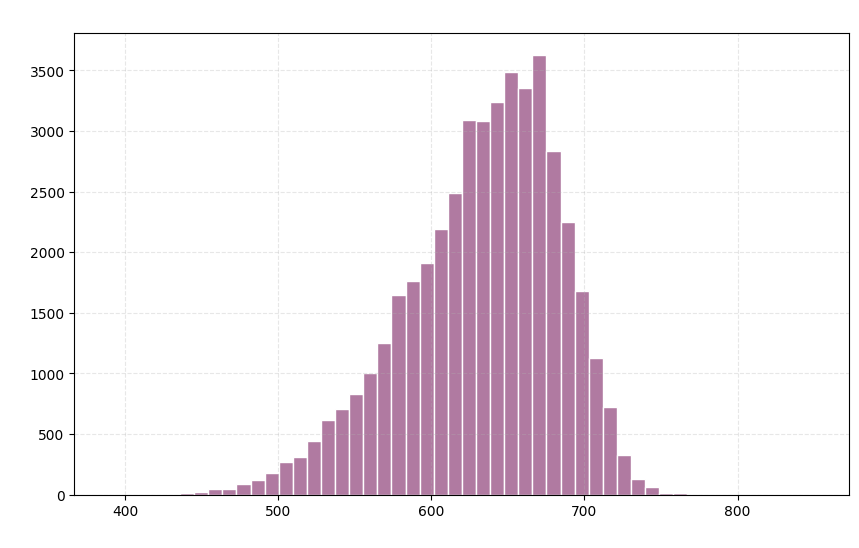

In [15]:
#show Distribution for Score
plt.figure(figsize=(10, 6))
plt.hist(df['credit_score'], bins=50, color='#B07AA1', edgecolor='white')
plt.title(' credit_score Distribution of Customers', fontsize=14, color='white')
plt.xlabel('credit_score', color='white')
plt.ylabel('Frequency', color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

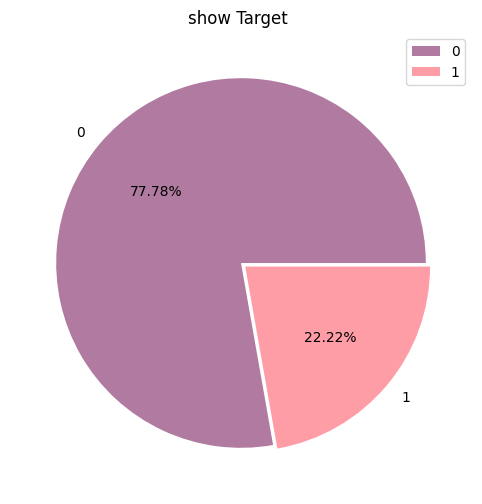

In [16]:
#show Target columns Analysis
consistent_colors = [  '#B07AA1', '#FF9DA7']
plt.figure(figsize=(10,6))
explode = (0,0.03)
plt.pie(df['loan_status'].value_counts().values,
        labels=df['loan_status'].value_counts().index,
        colors=consistent_colors[:len(df['loan_status'].value_counts())],
        explode=explode,
        autopct="%1.2f%%",
        )
plt.title('show Target ')
plt.legend()
plt.show()

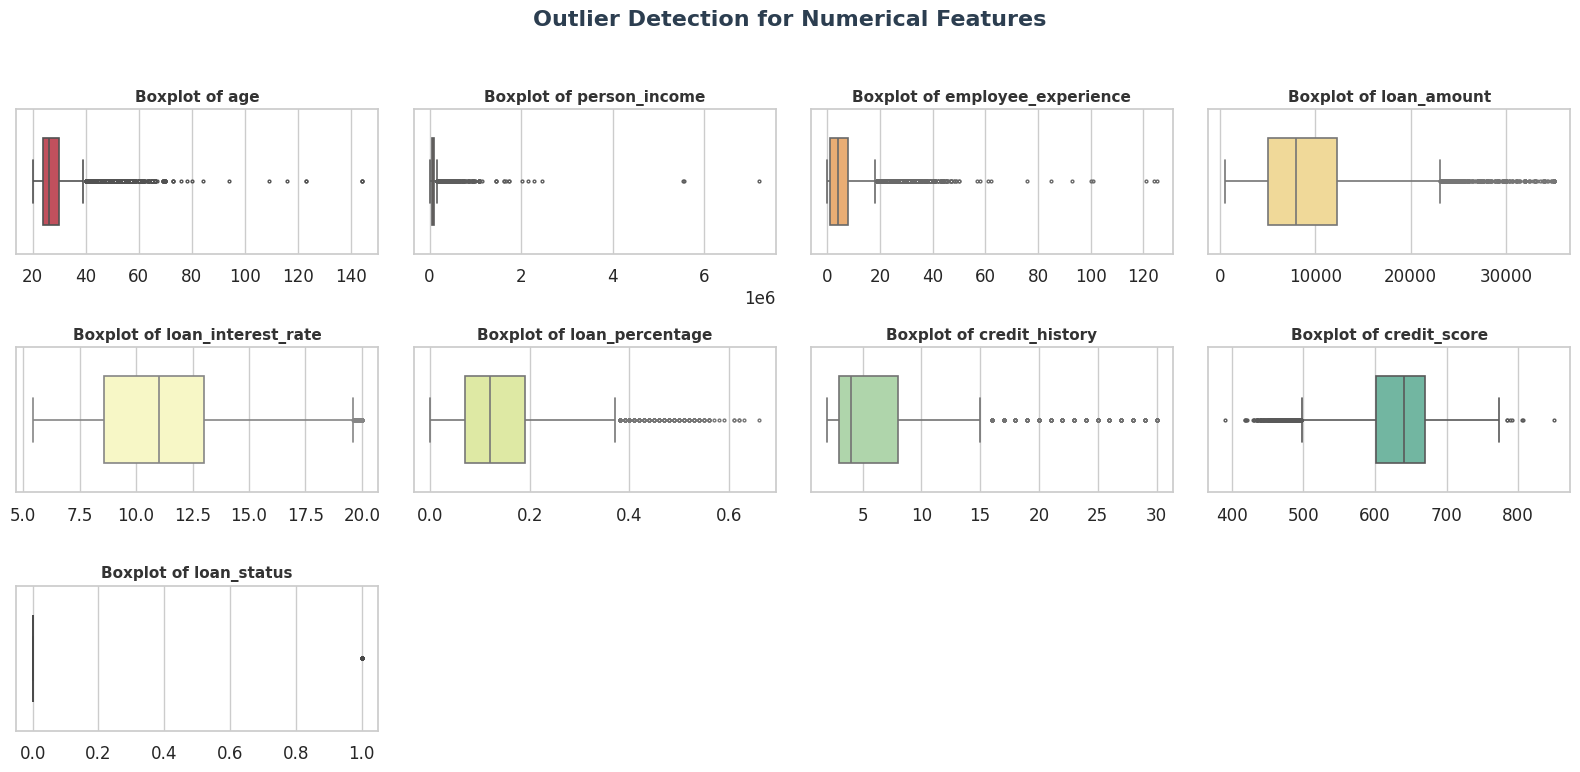

In [17]:
# Select numerical columns
numerical = df.select_dtypes(include=['int64', 'float64']).columns

# Set seaborn theme
sns.set(style="whitegrid", palette="Spectral", font_scale=1.1)

# Define color palette (vivid & unique)
palette = sns.color_palette("Spectral", len(numerical))

# Plot
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(
        x=df[col],
        color=palette[i-1],
        width=0.6,
        fliersize=2,
        linewidth=1.2
    )
    plt.title(f"Boxplot of {col}", fontsize=11, fontweight="bold", color="#333333")
    plt.xlabel("")
plt.suptitle("Outlier Detection for Numerical Features", fontsize=16, fontweight="bold", color="#2c3e50")
plt.tight_layout(rect=[0, 0, 1, 0.96])  # space for suptitle
plt.show()


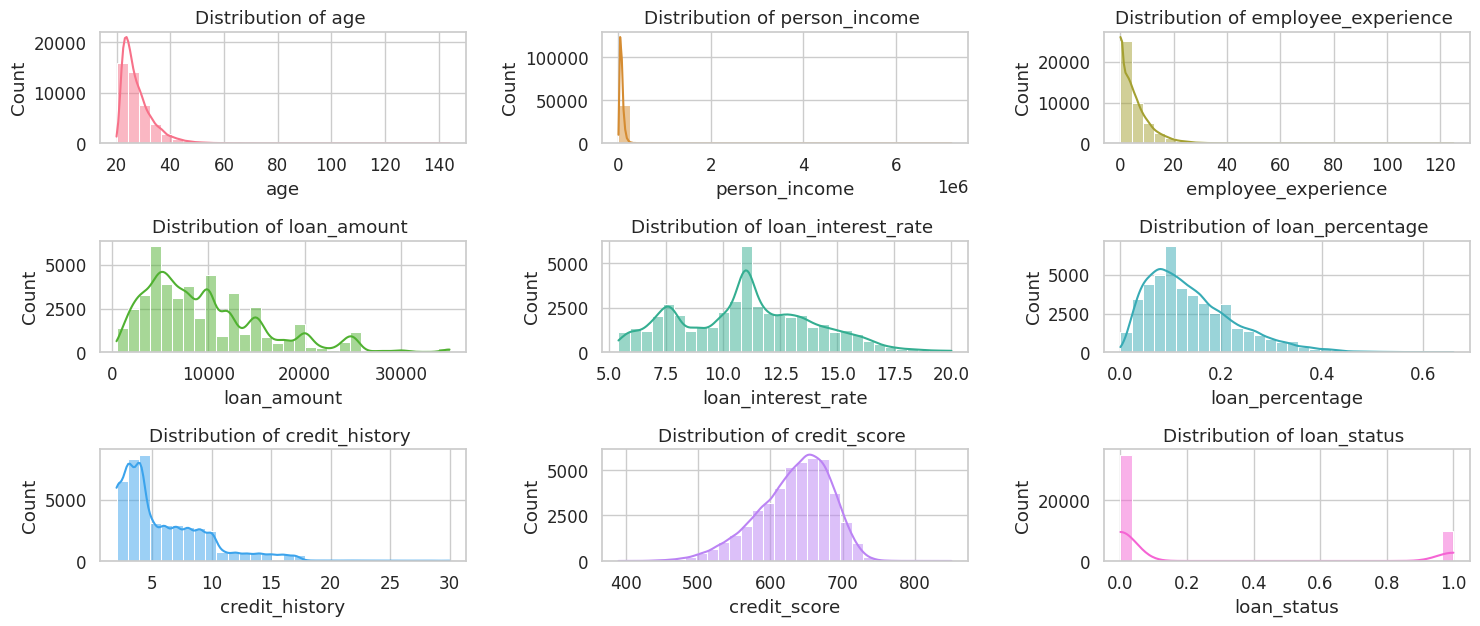

In [18]:
#show Distribution for all numerical columns
palette =sns.color_palette("husl",len(numerical))

plt.figure(figsize=(15,8))

#for loop
for i,col in enumerate(numerical,1):
    plt.subplot(4,3,i)
    sns.histplot(df[col],kde=True ,color=palette[i-1], bins=30)
    plt.title(f'Distribution of {col} ')

plt.tight_layout()
plt.show()

# Relationship between catagorical columns and target column


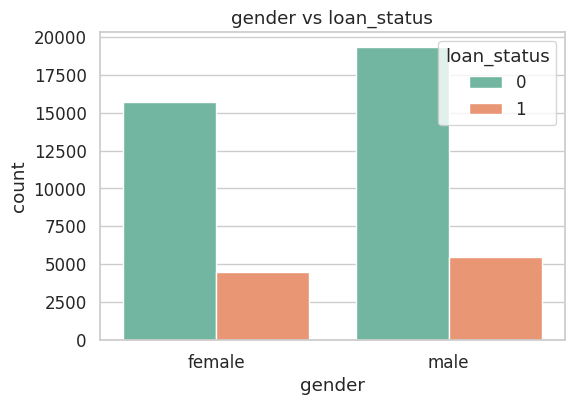

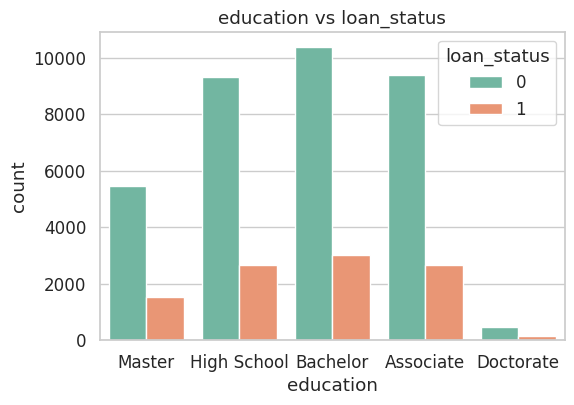

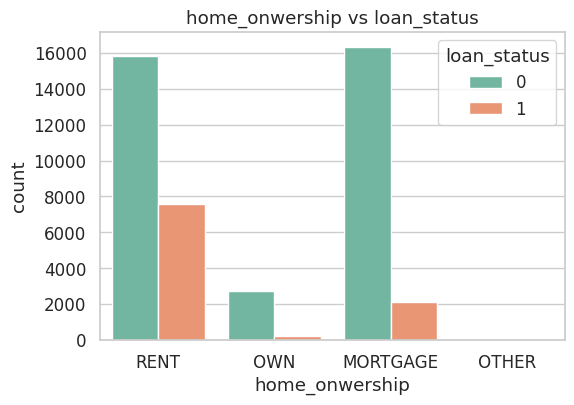

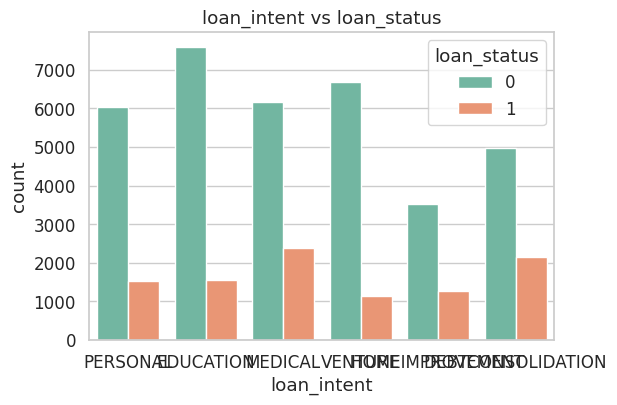

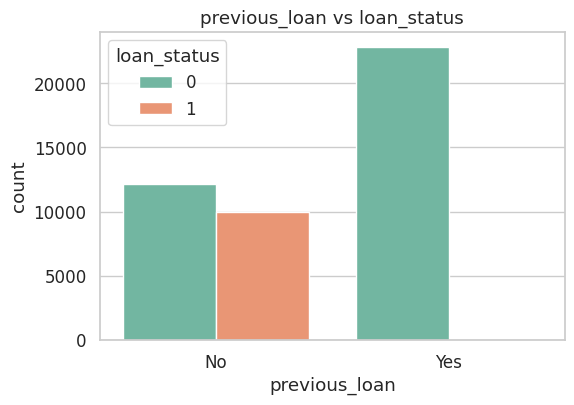

In [19]:
df.columns = df.columns.str.strip()

target = "loan_status"

# Categorical
categorical = ["gender","education", "home_onwership", "loan_intent","previous_loan"]
for col in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue=target, data=df, palette="Set2")
    plt.title(f"{col} vs {target}")
    plt.show()

# Relationship between numerical columns and target column

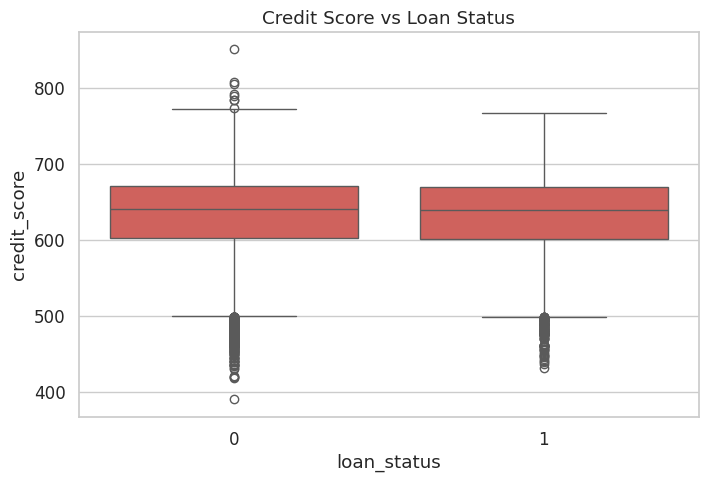

In [20]:
# credit_score vs loan_status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="credit_score"
)

plt.title("Credit Score vs Loan Status")

plt.show()

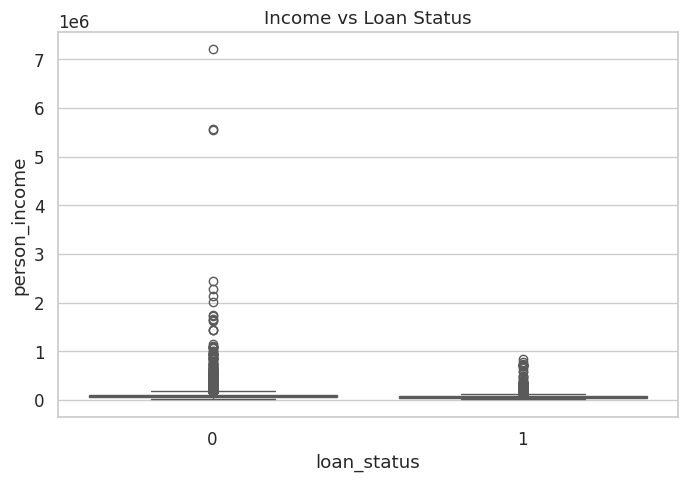

In [21]:
# income vs loan_status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income"
)

plt.title("Income vs Loan Status")

plt.show()

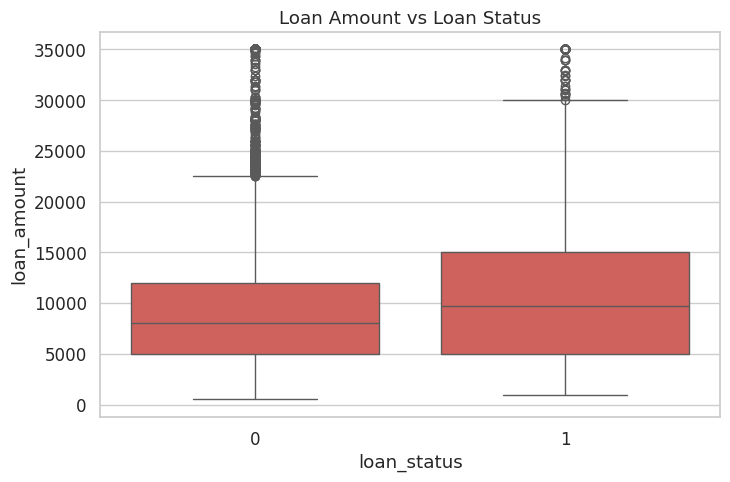

In [22]:
# loan amount vs loan_status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_amount"
)

plt.title("Loan Amount vs Loan Status")

plt.show()

# Correlation


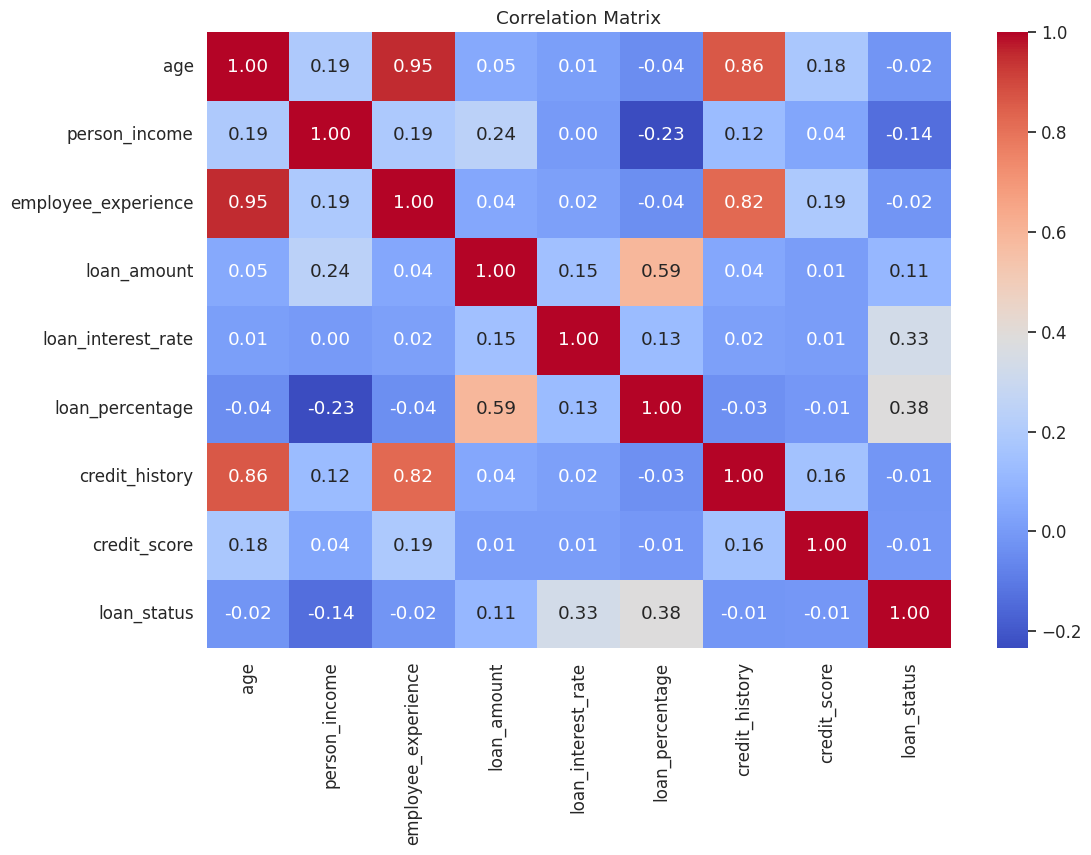

In [23]:
# correlation metrix
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [24]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target variable
numerical_columns.remove("loan_status")

print(numerical_columns)

['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score']


In [25]:
# outlier remove
df_clean = df.copy()

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (45000, 14)
After outlier removal: (36065, 14)


In [26]:
df=df_clean

# feature engineering


In [27]:
# Income to loan ratio
# ILR= person income/loan amount
df["income_loan_ratio"] = (
    df["person_income"] /
    df["loan_amount"]
)


In [28]:
# Loan to Income ratio
# LI= loan amount/person
df["loan_to_income"] = (
    df["loan_amount"] /
    df["person_income"]
)
# How larg is the requested loan relative to the aplicant's income

In [29]:
df.head()

,age,gender,education,person_income,employee_experience,home_onwership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status,income_loan_ratio,loan_to_income
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0,12.282000,0.081420
5,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1,5.180400,0.193035
9,21,female,High School,12739,0,OWN,1600,VENTURE,14.74,0.13,3,640,No,1,7.961875,0.125599
19,24,female,Master,14283,1,MORTGAGE,1750,EDUCATION,10.99,0.12,2,679,No,1,8.161714,0.122523
23,24,female,Bachelor,13866,0,OWN,1500,PERSONAL,7.29,0.11,3,600,Yes,0,9.244000,0.108178


# Encoding catagorical column

In [30]:
# Encode to categorical one hot encoding
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['home_onwership'] = le.fit_transform(df['home_onwership'])
df['loan_intent'] = le.fit_transform(df['loan_intent'])
df['previous_loan'] = le.fit_transform(df['previous_loan'])
df['gender'] = le.fit_transform(df['gender'])

#  data to train & test

In [31]:
# selecting x & y
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [32]:
#  Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28852, 15)
Test shape: (7213, 15)


# Logistic regression model

In [33]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== Logistic Regression ===
Accuracy: 0.8813253847220297
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5755
           1       0.72      0.69      0.70      1458

    accuracy                           0.88      7213
   macro avg       0.82      0.81      0.81      7213
weighted avg       0.88      0.88      0.88      7213



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Decision Tree Model

In [34]:
# Decision Tree
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [35]:
y_pred_tree = tree.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

=== Decision Tree ===
Accuracy: 0.9166782198807708
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5755
           1       0.89      0.67      0.76      1458

    accuracy                           0.92      7213
   macro avg       0.91      0.82      0.86      7213
weighted avg       0.92      0.92      0.91      7213



# Random forest Model

In [36]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [37]:
# Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.9255510883127687
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      5755
           1       0.87      0.74      0.80      1458

    accuracy                           0.93      7213
   macro avg       0.90      0.86      0.88      7213
weighted avg       0.92      0.93      0.92      7213



# Hyper-parameter tuning

In [38]:
# Import
from sklearn.model_selection import GridSearchCV

# Define parameters
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10,20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best model
best_rf = grid_search.best_estimator_

# Prediction
y_pred_best = best_rf.predict(X_test)

# Evaluation
print("=== Tuned Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
=== Tuned Random Forest ===
Accuracy: 0.9225010397892693
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5755
           1       0.86      0.73      0.79      1458

    accuracy                           0.92      7213
   macro avg       0.90      0.85      0.87      7213
weighted avg       0.92      0.92      0.92      7213

